# Threshold Boolean Formalism: Attractor Landscape and Update Dynamics

This interactive notebook expands on the simulation of Gene Regulatory Networks (GRNs) using the Threshold Boolean formalism. It introduces advanced analysis of the State Transition Graph (STG), specifically focusing on identifying steady states (attractors) versus transient states, quantifying the size of their basins of attraction, and demonstrating the fundamental differences between synchronous and asynchronous update schemes regarding determinism and bistability.

Importing the required libraries.

In [17]:
import pandas as pd
import numpy as np
import networkx as nx
from matplotlib import pyplot as plt
import seaborn as sns
import os
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 150

## 1. Reading Network Topologies

In [2]:
def parse_topo(topo_path):
    """
    Reads a .topo file and converts it into an adjacency matrix.
    Type 2 interactions (inhibitory) are converted to -1 weights.
    """
    topo_df = pd.read_csv(topo_path, sep=r"\s+")
    topo_df["Type"] = topo_df["Type"].replace({2: -1})

    topo_net = nx.from_pandas_edgelist(
        topo_df, source="Source", target="Target", edge_attr="Type", create_using=nx.DiGraph
    )

    nodes = list(topo_net.nodes())
    topo_adj = nx.to_numpy_array(topo_net, nodelist=nodes, weight="Type")

    return topo_adj, nodes

## 2. Core Simulation Logic

In [19]:
def gen_initialconds(num_nodes, num_initconds=100):
    """Generates random initial conditions strictly inside the {-1, 1} coordinate space."""
    return np.random.choice([-1, 1], size=(num_initconds, num_nodes))

def ising_simulate_sync(adjmat, initcond, num_steps):
    """Synchronous execution rule: All nodes update concurrently."""
    state_list = [initcond.copy()]
    for _ in range(num_steps):
        # Matrix multiplication using true {-1, 1} values
        input_sum = adjmat @ state_list[-1]

        new_state = np.where(input_sum > 0, 1, -1)

        state_list.append(new_state)
    return state_list

def ising_simulate_async(adjmat, initcond, num_steps):
    """Asynchronous execution rule: One random node updates per time increment."""
    state_list = [initcond.copy()]
    for _ in range(num_steps):
        current_state = state_list[-1].copy()
        node_to_update = np.random.randint(len(current_state))

        input_sum = adjmat[node_to_update, :] @ current_state

        if input_sum > 0:
            current_state[node_to_update] = 1
        else:
            current_state[node_to_update] = -1

        state_list.append(current_state)
    return state_list

def ising_simulate(adjmat, initcond_array, node_list, num_steps, update_mode):
    """Orchestrates network runs across an input array of initial states."""
    simul_df = []
    for initcond_num, initcond in enumerate(initcond_array):
        if update_mode == "async":
            state_history = ising_simulate_async(adjmat, initcond, num_steps)
        elif update_mode == "sync":
            state_history = ising_simulate_sync(adjmat, initcond, num_steps)
        else:
            raise ValueError("Unknown execution mode specified.")

        state_df = pd.DataFrame(state_history, columns=node_list)
        state_df["Step"] = range(1, len(state_df) + 1)
        state_df["InitCondNum"] = initcond_num + 1

        state_df[node_list] = state_df[node_list].replace(-1, 0)
        simul_df.append(state_df)

    return pd.concat(simul_df, axis=0)

## 3. State Transition Graph (STG) and Steady State Identification

A state is considered **Stable (Steady State / Attractor)** if all its outgoing transitions point back to itself. All other states are **Transient**.

In [4]:
def get_stg_and_landscapes(simul_result, node_list, global_num_ics):
    """
    Computes the STG and extracts the true attractor landscape frequency
    directly from the graph's structural properties, differentiating
    fixed points from limit cycles without requiring prior pre-calculation.
    """
    # 1. Format state strings from simulation traces
    simul_result[node_list] = simul_result[node_list].astype(int)
    simul_result["State"] = simul_result[node_list].astype(str).agg("".join, axis=1)

    # 2. Build the state transition edge data
    stg_list = []
    for _, group in simul_result.groupby("InitCondNum"):
        group = group.sort_values("Step").reset_index(drop=True)
        group_stg = group[["State", "InitCondNum", "Step"]].copy()
        group_stg.loc[:, "Next_State"] = group_stg["State"].shift(-1)
        group_stg = group_stg.dropna(subset=["Next_State"])
        stg_list.append(group_stg[["State", "Next_State", "InitCondNum"]])

    stg_df = pd.concat(stg_list, axis=0)
    edge_counts = stg_df.groupby(["State", "Next_State"]).size().reset_index(name="Count")

    # 3. Build a NetworkX graph to analyze topology properties
    temp_g = nx.from_pandas_edgelist(edge_counts, source="State", target="Next_State", create_using=nx.DiGraph())

    # 4. Identify True Steady States (Sinks) directly from Graph Topology
    # A node is a true steady state if its out-degree is 1 (self-loop) or 0 (simulation terminal boundary)
    # AND it has no outgoing paths to any other distinct state.
    true_steady_states = set()
    for node in temp_g.nodes():
        successors = list(temp_g.successors(node))
        if len(successors) == 0 or (len(successors) == 1 and successors[0] == node):
            true_steady_states.add(node)

    # 5. Calculate Attractor Landscape frequencies based on Initial Conditions
    # Find where each individual initial condition trajectory ended up
    idx = simul_result.groupby("InitCondNum")["Step"].idxmax()
    final_states = simul_result.loc[idx, ["InitCondNum", "State"]].set_index("InitCondNum")

    resolved_endpoints = []
    for ic_num in range(1, global_num_ics + 1):
        if ic_num in final_states.index:
            # Handle potential duplicate indexes from replicated async entries safely
            ic_endpoints = final_states.loc[ic_num]
            if isinstance(ic_endpoints, pd.DataFrame):
                states_to_check = ic_endpoints["State"].unique()
            else:
                states_to_check = [ic_endpoints["State"]]

            for state in states_to_check:
                if state in true_steady_states:
                    resolved_endpoints.append(state)
                else:
                    resolved_endpoints.append("Transient")

    # Generate the relative frequency distribution profile
    resolved_series = pd.Series(resolved_endpoints)
    freq_dist = resolved_series.value_counts(normalize=True).reset_index()
    freq_dist.columns = ["Steady_State", "Frequency"]

    return edge_counts, np.array(list(true_steady_states)), freq_dist


def get_stg_and_landscapes2(simul_result, node_list, global_num_ics):
    """
    Computes the STG and extracts the true attractor landscape frequency.
    Differentiates fixed points from limit cycles accurately across both
    synchronous and asynchronous update traces.
    """
    # 1. Format state strings from simulation traces
    simul_result[node_list] = simul_result[node_list].astype(int)
    simul_result["State"] = simul_result[node_list].astype(str).agg("".join, axis=1)

    # 2. Build the state transition edge data
    stg_list = []
    for _, group in simul_result.groupby("InitCondNum"):
        group = group.sort_values("Step").reset_index(drop=True)
        group_stg = group[["State", "InitCondNum", "Step"]].copy()
        group_stg.loc[:, "Next_State"] = group_stg["State"].shift(-1)
        group_stg = group_stg.dropna(subset=["Next_State"])
        stg_list.append(group_stg[["State", "Next_State", "InitCondNum"]])

    stg_df = pd.concat(stg_list, axis=0)
    edge_counts = stg_df.groupby(["State", "Next_State"]).size().reset_index(name="Count")

    # 3. Identify True Steady States (Sinks) directly using self-loop logic
    # A state is a steady state if it transitions back to itself anywhere in the STG.
    true_steady_states = set(edge_counts[edge_counts["State"] == edge_counts["Next_State"]]["State"].unique())

    # 4. Calculate Attractor Landscape frequencies based on Initial Conditions
    # Determine the terminal behavior of each initial condition trajectory
    idx = simul_result.groupby("InitCondNum")["Step"].idxmax()
    final_states = simul_result.loc[idx, ["InitCondNum", "State"]].set_index("InitCondNum")

    resolved_endpoints = []
    for ic_num in range(1, global_num_ics + 1):
        if ic_num in final_states.index:
            ic_endpoints = final_states.loc[ic_num]

            # Handle potential duplicate indexes from replicated async entries safely
            if isinstance(ic_endpoints, pd.DataFrame):
                states_to_check = ic_endpoints["State"].unique()
            else:
                states_to_check = [ic_endpoints["State"]]

            for state in states_to_check:
                if state in true_steady_states:
                    resolved_endpoints.append(state)
                else:
                    resolved_endpoints.append("Tansient")

    # Generate the relative frequency distribution profile
    resolved_series = pd.Series(resolved_endpoints)
    freq_dist = resolved_series.value_counts(normalize=True).reset_index()
    freq_dist.columns = ["Steady_State", "Frequency"]

    return edge_counts, np.array(list(true_steady_states)), freq_dist

## 4. Plotting STG and Attractor Frequencies

In [5]:
def plot_stg_annotated(stg_df, steady_states, update_mode, topo_name, result_dir):
    """Plots the STG using Kamada-Kawai layout, local annotations, and clean arrow terminations."""
    stg = nx.from_pandas_edgelist(
        stg_df, source="State", target="Next_State", edge_attr="Count", create_using=nx.DiGraph()
    )

    plt.figure(figsize=(6, 6))
    pos = nx.kamada_kawai_layout(stg)

    node_colors = ["#2ca02c" if node in steady_states else "#1f77b4" for node in stg.nodes()]
    NODE_SIZE = 900

    nx.draw_networkx_nodes(stg, pos, node_color=node_colors, edgecolors="white", node_size=NODE_SIZE, alpha=0.9)

    standard_edges = [(u, v) for u, v in stg.edges() if u != v]
    self_loop_edges = [(u, v) for u, v in stg.edges() if u == v]
    UNIFORM_WIDTH = 1.5

    if standard_edges:
        nx.draw_networkx_edges(
            stg, pos, edgelist=standard_edges, width=UNIFORM_WIDTH,
            arrowsize=12, arrowstyle="->", node_size=NODE_SIZE,
            min_target_margin=18, edge_color="gray",
            connectionstyle="arc3,rad=0.2", alpha=0.6
        )

    if self_loop_edges:
        nx.draw_networkx_edges(
            stg, pos, edgelist=self_loop_edges, width=UNIFORM_WIDTH,
            arrowsize=12, arrowstyle="->", node_size=NODE_SIZE,
            min_target_margin=12, edge_color="#2ca02c",
            connectionstyle="arc3,rad=0.5", alpha=0.8
        )

    nx.draw_networkx_labels(stg, pos, font_size=9, font_weight="bold")

    # Textual transition weights placed cleanly on the midpoint of graph arcs
    edge_labels = {k: f"{v:.2f}" for k, v in nx.get_edge_attributes(stg, "Count").items() if k[0] != k[1]}
    nx.draw_networkx_edge_labels(stg, pos, edge_labels=edge_labels, font_size=7, label_pos=0.5, rotate=True)

    import matplotlib.patches as mpatches
    stable_patch = mpatches.Patch(color='#2ca02c', label='Stable State (Attractor)')
    transient_patch = mpatches.Patch(color='#1f77b4', label='Transient State')
    plt.legend(handles=[stable_patch, transient_patch], loc='center left', bbox_to_anchor=(1.05, 0.5))

    plt.title(f"State Transition Graph\n{topo_name} ({update_mode})", fontsize=12, pad=15)
    plt.axis("off")

    topo_out_dir = os.path.join(result_dir, topo_name)
    plt.savefig(os.path.join(topo_out_dir, f"{topo_name}_STG_{update_mode}.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

def plot_steady_state_distribution(freq_dist, update_mode, topo_name, result_dir):
    """Plots bounded frequency distribution of final steady states across run conditions."""
    plt.figure(figsize=(8, 5))
    sns.barplot(data=freq_dist, x="Steady_State", y="Frequency", hue="Steady_State", palette="viridis", legend=False)

    plt.title(f"Steady State Frequency Distribution\n{topo_name} ({update_mode})", fontsize=14)
    plt.xlabel("Steady State (Binary Profile)", fontsize=12)
    plt.ylabel("Relative Frequency", fontsize=12)

    max_freq = freq_dist["Frequency"].max() if not freq_dist.empty else 1
    plt.ylim(0, max_freq * 1.15)

    for index, row in freq_dist.iterrows():
        plt.text(index, row.Frequency + (max_freq * 0.02), f"{row.Frequency:.2f}", color='black', ha="center")

    topo_out_dir = os.path.join(result_dir, topo_name)
    plt.savefig(os.path.join(topo_out_dir, f"{topo_name}_FreqDist_{update_mode}.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

## 5. Comparing Synchronus and Asynchronus Steady-State Frequency Distributions

In [20]:
def generate_consolidated_topology_report(topo_adj, node_list, topo_name, result_dir, init_conds, num_steps=25):
    """
    Compiles structural graphs and true attractor landscapes side-by-side
    into a single layout canvas, safely isolating cycles from fixed-point sinks.
    """
    global_num_ics = len(init_conds)

    # 1. Run Simulations
    sync_res = ising_simulate(topo_adj, init_conds, node_list, num_steps, "sync")
    replicated_ics = np.repeat(init_conds, 5, axis=0)
    async_res = ising_simulate(topo_adj, replicated_ics, node_list, num_steps, "async")
    async_res["InitCondNum"] = np.repeat(np.arange(1, global_num_ics + 1), 5 * (num_steps + 1))

    # --- FIX: Replaced the obsolete 'get_stg_and_states' call with the corrected 'get_stg_and_landscapes' function ---
    sync_edges, sync_steady, sync_freq = get_stg_and_landscapes2(sync_res, node_list, global_num_ics)
    async_edges, async_steady, async_freq = get_stg_and_landscapes2(async_res, node_list, global_num_ics)

    fig = plt.figure(figsize=(20, 10))
    grid = fig.add_gridspec(2, 3, wspace=0.3, hspace=0.3)

    sync_steady_set = set(str(s) for s in sync_steady)
    async_steady_set = set(str(s) for s in async_steady)

    # Panel 1: Synchronous STG
    ax_stg_sync = fig.add_subplot(grid[0, 0])
    g_sync = nx.from_pandas_edgelist(sync_edges, source="State", target="Next_State", create_using=nx.DiGraph())
    pos_sync = nx.kamada_kawai_layout(g_sync)
    nx.draw_networkx_nodes(g_sync, pos_sync, node_color=["#2ca02c" if str(n) in sync_steady_set else "#1f77b4" for n in g_sync.nodes()], node_size=500, ax=ax_stg_sync)
    nx.draw_networkx_edges(g_sync, pos_sync, arrowstyle="->", arrowsize=10, min_target_margin=15, edge_color="gray", connectionstyle="arc3,rad=0.2", ax=ax_stg_sync)
    nx.draw_networkx_labels(g_sync, pos_sync, font_size=8, font_weight="bold", ax=ax_stg_sync)
    ax_stg_sync.set_title(f"Synchronous STG (True Sinks in Green: {len(sync_steady)})", fontsize=12, fontweight="bold")
    ax_stg_sync.axis("off")

    # Panel 2: Asynchronous STG
    ax_stg_async = fig.add_subplot(grid[1, 0])
    g_async = nx.from_pandas_edgelist(async_edges, source="State", target="Next_State", create_using=nx.DiGraph())
    pos_async = nx.kamada_kawai_layout(g_async)
    nx.draw_networkx_nodes(g_async, pos_async, node_color=["#2ca02c" if str(n) in async_steady_set else "#1f77b4" for n in g_async.nodes()], node_size=500, ax=ax_stg_async)
    nx.draw_networkx_edges(g_async, pos_async, arrowstyle="->", arrowsize=10, min_target_margin=15, edge_color="gray", connectionstyle="arc3,rad=0.2", ax=ax_stg_async)
    nx.draw_networkx_labels(g_async, pos_async, font_size=8, font_weight="bold", ax=ax_stg_async)
    ax_stg_async.set_title(f"Asynchronous STG (True Sinks in Green: {len(async_steady)})", fontsize=12, fontweight="bold")
    ax_stg_async.axis("off")

    # Color helper function for bar plot categories
    def get_palette(df):
        return ["#d62728" if state == "Limit Cycle" else "#bcbd22" for state in df["Steady_State"]]

    # Panel 3: Sync Basin Weights
    ax_freq_sync = fig.add_subplot(grid[0, 1])
    if not sync_freq.empty:
        sns.barplot(data=sync_freq, x="Steady_State", y="Frequency", hue="Steady_State", palette=get_palette(sync_freq), legend=False, ax=ax_freq_sync)
        ax_freq_sync.set_ylim(0, sync_freq["Frequency"].max() * 1.15)
        for i, r in sync_freq.iterrows():
            ax_freq_sync.text(i, r.Frequency + 0.02, f"{r.Frequency:.2f}", ha="center", fontsize=9)
    ax_freq_sync.set_title("Synchronous Landscape Distribution", fontsize=11, fontweight="bold")

    # Panel 4: Async Basin Weights
    ax_freq_async = fig.add_subplot(grid[1, 1])
    if not async_freq.empty:
        sns.barplot(data=async_freq, x="Steady_State", y="Frequency", hue="Steady_State", palette=get_palette(async_freq), legend=False, ax=ax_freq_async)
        ax_freq_async.set_ylim(0, async_freq["Frequency"].max() * 1.15)
        for i, r in async_freq.iterrows():
            ax_freq_async.text(i, r.Frequency + 0.02, f"{r.Frequency:.2f}", ha="center", fontsize=9)
    ax_freq_async.set_title("Asynchronous Landscape Distribution", fontsize=11, fontweight="bold")

    # Panel 5: Grouped Global Comparison
    ax_cmp = fig.add_subplot(grid[:, 2])
    sync_freq["Update_Mode"] = "Synchronous"
    async_freq["Update_Mode"] = "Asynchronous"
    combined = pd.concat([sync_freq, async_freq], axis=0)

    sns.barplot(data=combined, x="Steady_State", y="Frequency", hue="Update_Mode", palette={"Synchronous": "#1f77b4", "Asynchronous": "#a90c0c"}, ax=ax_cmp)
    ax_cmp.set_title("Unified Landscape Attractor Comparison", fontsize=12, fontweight="bold")
    ax_cmp.set_ylim(0, combined["Frequency"].max() * 1.15)

    for p in ax_cmp.patches:
        h = p.get_height()
        if h > 0:
            ax_cmp.text(p.get_x() + p.get_width() / 2.0, h + 0.015, f"{h:.2f}", ha="center", va="bottom", fontsize=9)

    fig.suptitle(f"Simulation Summary: {topo_name}", fontsize=16, fontweight="bold", y=0.96)

    topo_out_dir = os.path.join(result_dir, topo_name)
    plt.savefig(os.path.join(topo_out_dir, f"{topo_name}_Report.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


## 6. Demonstrating Bistability: Synchronous vs Asynchronous

* **Synchronous Determinism:** Because all nodes evaluate their inputs at time $t$ to dictate state at $t+1$, a given initial condition follows exactly one trajectory. The network will *always* reach the identical steady state (or cyclic attractor).
* **Asynchronous Bistability/Multistability:** Because nodes update randomly one at a time, trajectories branch. A single initial condition situated near a basin boundary can diverge, leading the network to different stable steady states purely due to update stochasticity.

In [15]:
def demonstrate_bistability(adjmat, node_list, topo_name, result_dir, num_runs=200, num_steps=20):
    """
    Takes a single random initial condition configuration, runs it through repeated
    stochastic trajectories under both update modes, and uses unified graph topology
    to demonstrate synchronous determinism vs. asynchronous multi-replicate bistability.
    """
    # Select ONE random initial condition in the true {-1, 1} coordinate system
    single_ic = gen_initialconds(len(node_list), num_initconds=1)[0]

    # Tile it to simulate the EXACT SAME initial state configuration space multiple times
    ic_array = np.tile(single_ic, (num_runs, 1))

    print(f"\n--- Bistability Local Divergence Check: {topo_name} ---")
    print(f"Initial Condition selected (Binary Profile): {np.where(single_ic == -1, 0, 1)}")

    # Run and analyze Synchronous mode trajectories
    sync_res = ising_simulate(adjmat, ic_array, node_list, num_steps, "sync")
    _, _, sync_freq = get_stg_and_landscapes(sync_res, node_list, num_runs)

    # Run and analyze Asynchronous mode trajectories
    async_res = ising_simulate(adjmat, ic_array, node_list, num_steps, "async")
    _, _, async_freq = get_stg_and_landscapes(async_res, node_list, num_runs)

    # Visualization layout instantiation
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    # Panel Color palettes mapping helper
    def get_palette(df, base_color):
        return ["#d62728" if s == "Limit Cycle" else base_color for s in df["Steady_State"]]

    # Panel 1: Synchronous Determinism Distribution Trace
    if not sync_freq.empty:
        sns.barplot(data=sync_freq, x="Steady_State", y="Frequency", hue="Steady_State",
                    palette=get_palette(sync_freq, "#1f77b4"), legend=False, ax=axes[0])
        axes[0].set_ylim(0, max(sync_freq["Frequency"].max() * 1.15, 1.05))
        for i, r in sync_freq.iterrows():
            axes[0].text(i, r.Frequency + 0.02, f"{r.Frequency:.2f}", ha="center", fontsize=9)
    axes[0].set_title("Synchronous Update\n(100% Deterministic Trajectory)", fontsize=11)
    axes[0].set_xlabel("Attractor End Point")
    axes[0].set_ylabel("Relative Divergence Frequency")

    # Panel 2: Asynchronous Stochastic Branching Distribution Trace
    if not async_freq.empty:
        sns.barplot(data=async_freq, x="Steady_State", y="Frequency", hue="Steady_State",
                    palette=get_palette(async_freq, "#bcbd22"), legend=False, ax=axes[1])
        axes[1].set_ylim(0, max(async_freq["Frequency"].max() * 1.15, 1.05))
        for i, r in async_freq.iterrows():
            axes[1].text(i, r.Frequency + 0.02, f"{r.Frequency:.2f}", ha="center", fontsize=9)
    axes[1].set_title("Asynchronous Update\n(Stochastic Flips, Potential Bistability)", fontsize=11)
    axes[1].set_xlabel("Attractor End Point")

    fig.suptitle(f"Single State Coordinate Branching Analysis: {topo_name}", fontsize=13, fontweight='bold', y=0.98)
    plt.tight_layout()

    # Save chart asset to directory prior to showing figure to avoid clearing active axis bounds
    topo_out_dir = os.path.join(result_dir, topo_name)
    plt.savefig(os.path.join(topo_out_dir, f"{topo_name}_Bistability_Demo.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Synchronous final states for this baseline initial condition:\n{sync_freq.to_string(index=False)}")
    print(f"Asynchronous final states for this baseline initial condition:\n{async_freq.to_string(index=False)}")

## 7. Main Execution Pipeline

Setting up the collab instance by mounting the google drive and changing the working driectory to the required directory.

In [9]:
# Connecting the google drive folder
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [10]:
# Change the current working directory
os.chdir("/content/drive/MyDrive/BooleanPHCCO")
print(f"Current working Directory is : {os.getcwd()}")

Current working Directory is : /content/drive/MyDrive/BooleanPHCCO


Specifying the directory with the topo files and also getting the list of topo files using glob and pathlib library functions.

In [11]:
# Specifying the path to the topo files
topo_dir = Path("./TOPOS")
print(f"Direcotry with the topo files is {topo_dir.name}")

# Getting the list of topo files
topo_list = sorted(list(topo_dir.glob("*.topo")))
print(f"Network List: {topo_list}")
print(f"Number of newtorks : {len(topo_list)}")

Direcotry with the topo files is TOPOS
Network List: [PosixPath('TOPOS/TS.topo'), PosixPath('TOPOS/TSSA.topo'), PosixPath('TOPOS/TSSI.topo'), PosixPath('TOPOS/TT.topo'), PosixPath('TOPOS/TTSA.topo')]
Number of newtorks : 5


Setting simuation hyper-parameters

In [12]:
GLOBAL_NUM_ICS = 100
STEPS_PER_RUN = 100
ASYNC_REPLICATES = 5

Creating the result directory to save the results.

In [13]:
# Creating the result directory
result_dir = Path("./IsingResults")
result_dir.mkdir(exist_ok=True)

Looping through the netowrks, parsing, running simualtion and analysis.


Processing Topology: TS
Running sync simulation pipeline...
--- SYNC Metrics ---
  Total unique states transitions: 4
  Stable steady-state points:  2 (10, 01)
Running async simulation pipeline...
--- ASYNC Metrics ---
  Total unique states transitions: 10
  Stable steady-state points:  4 (11, 10, 01, 00)
Compiling consolidated summary for TS...


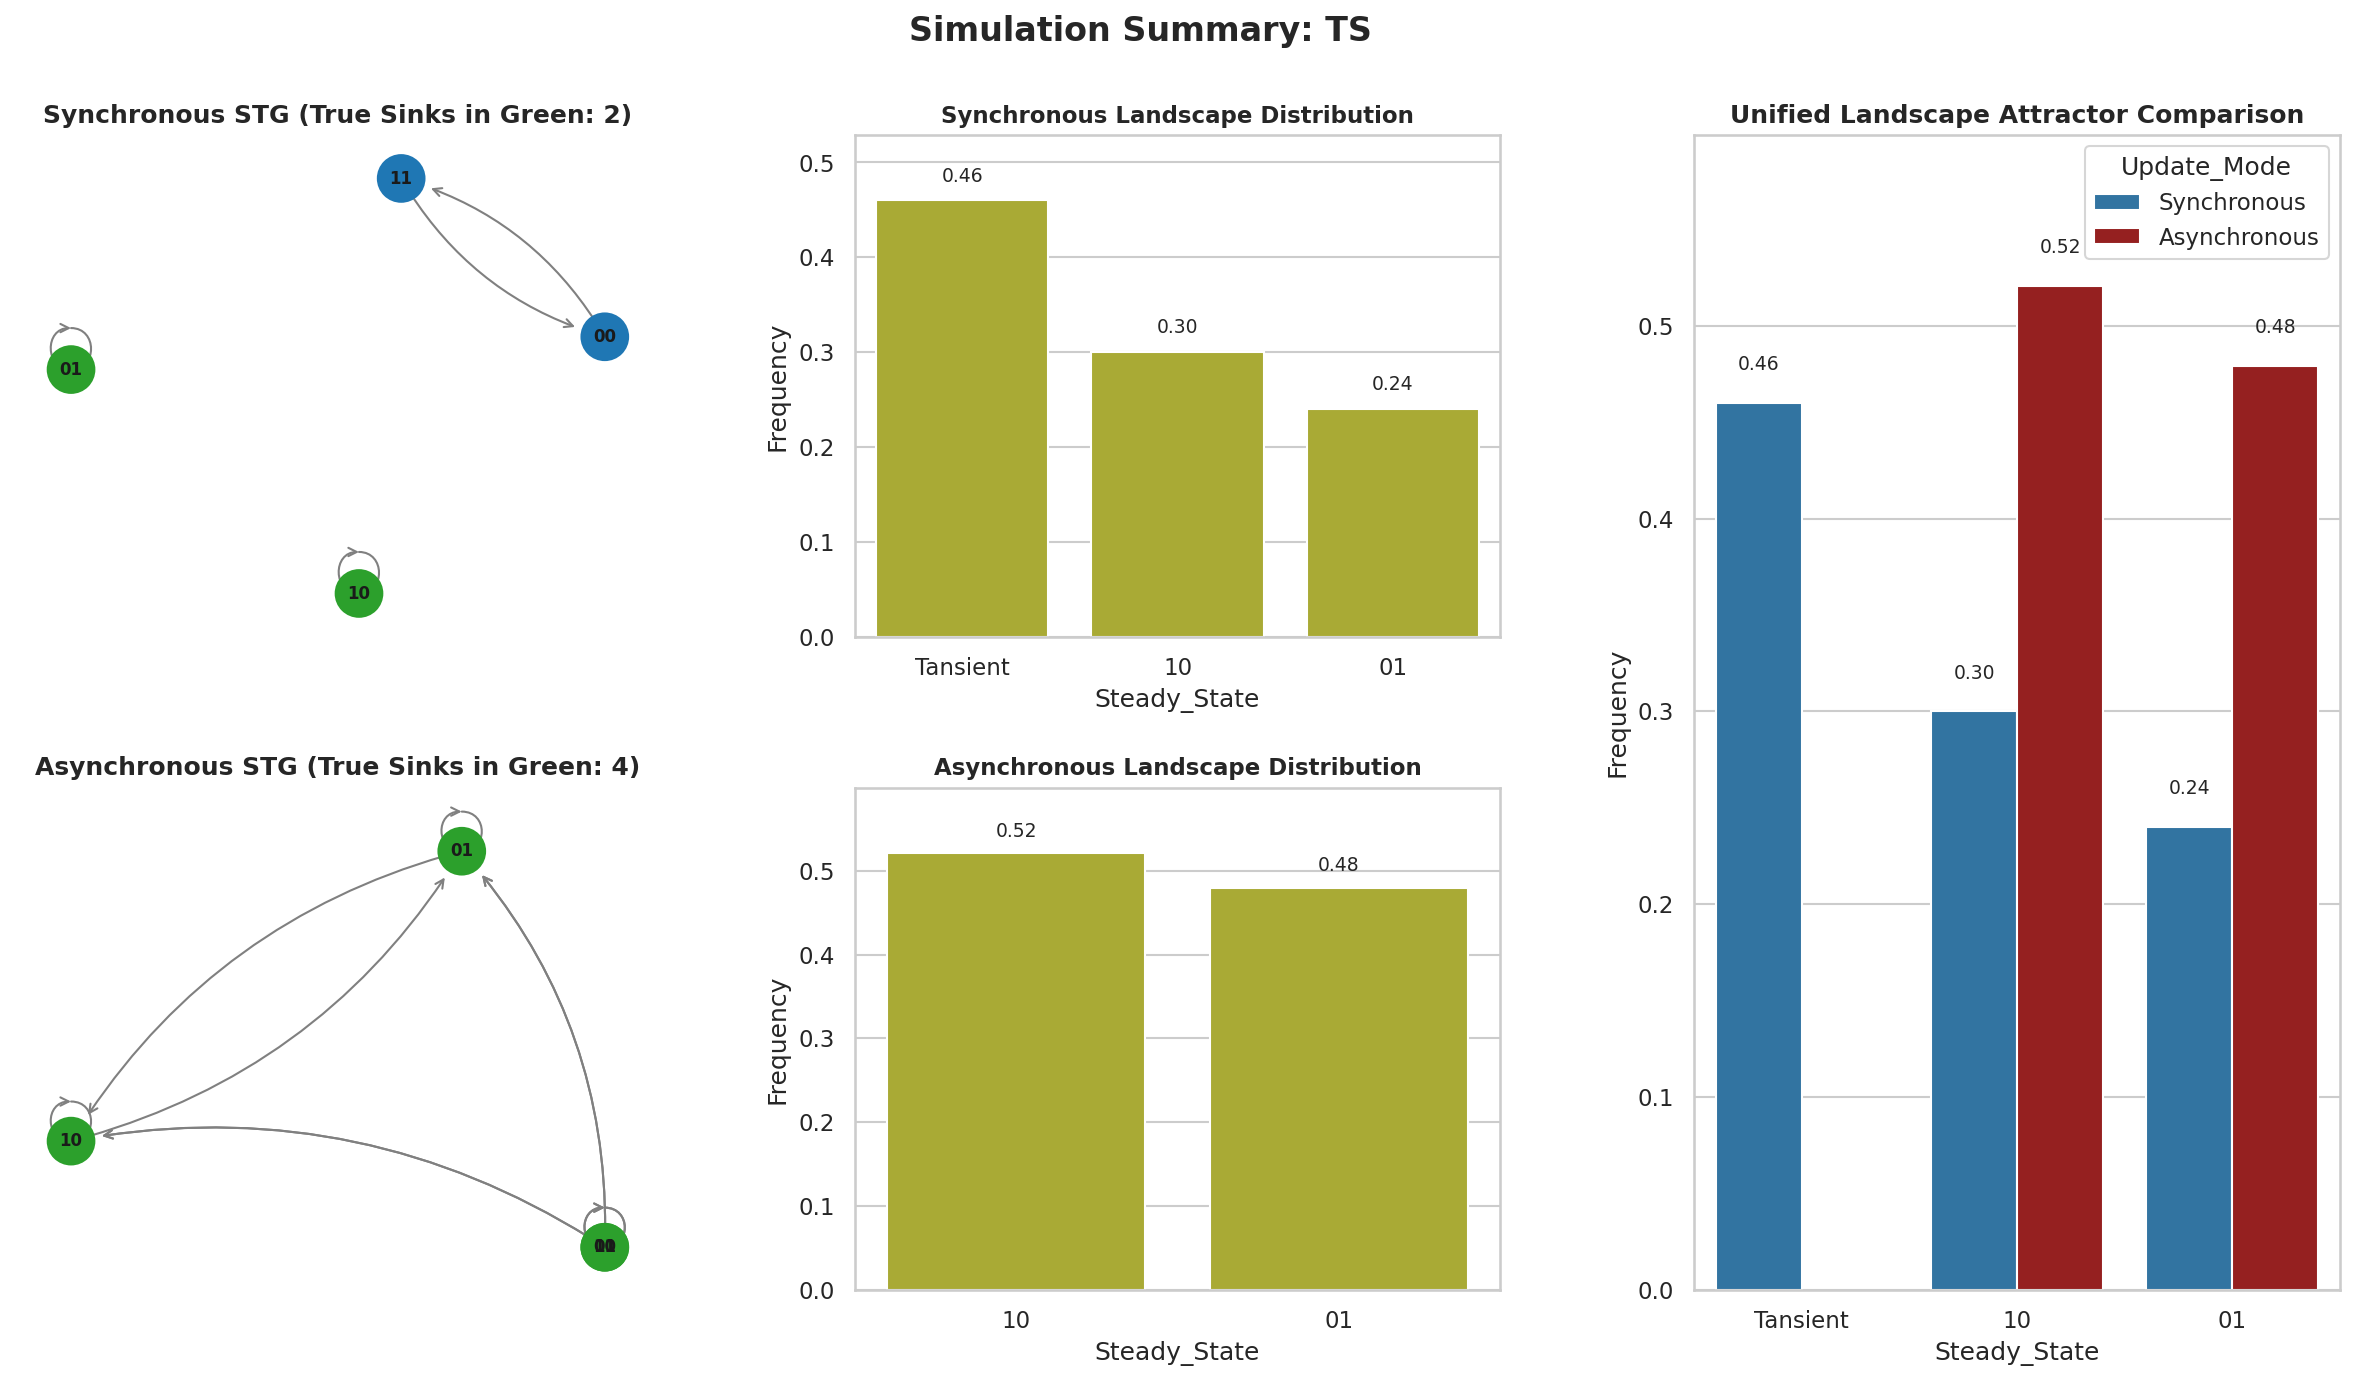


Processing Topology: TSSA
Running sync simulation pipeline...
--- SYNC Metrics ---
  Total unique states transitions: 4
  Stable steady-state points:  3 (10, 01, 00)
Running async simulation pipeline...
--- ASYNC Metrics ---
  Total unique states transitions: 8
  Stable steady-state points:  4 (11, 10, 01, 00)
Compiling consolidated summary for TSSA...


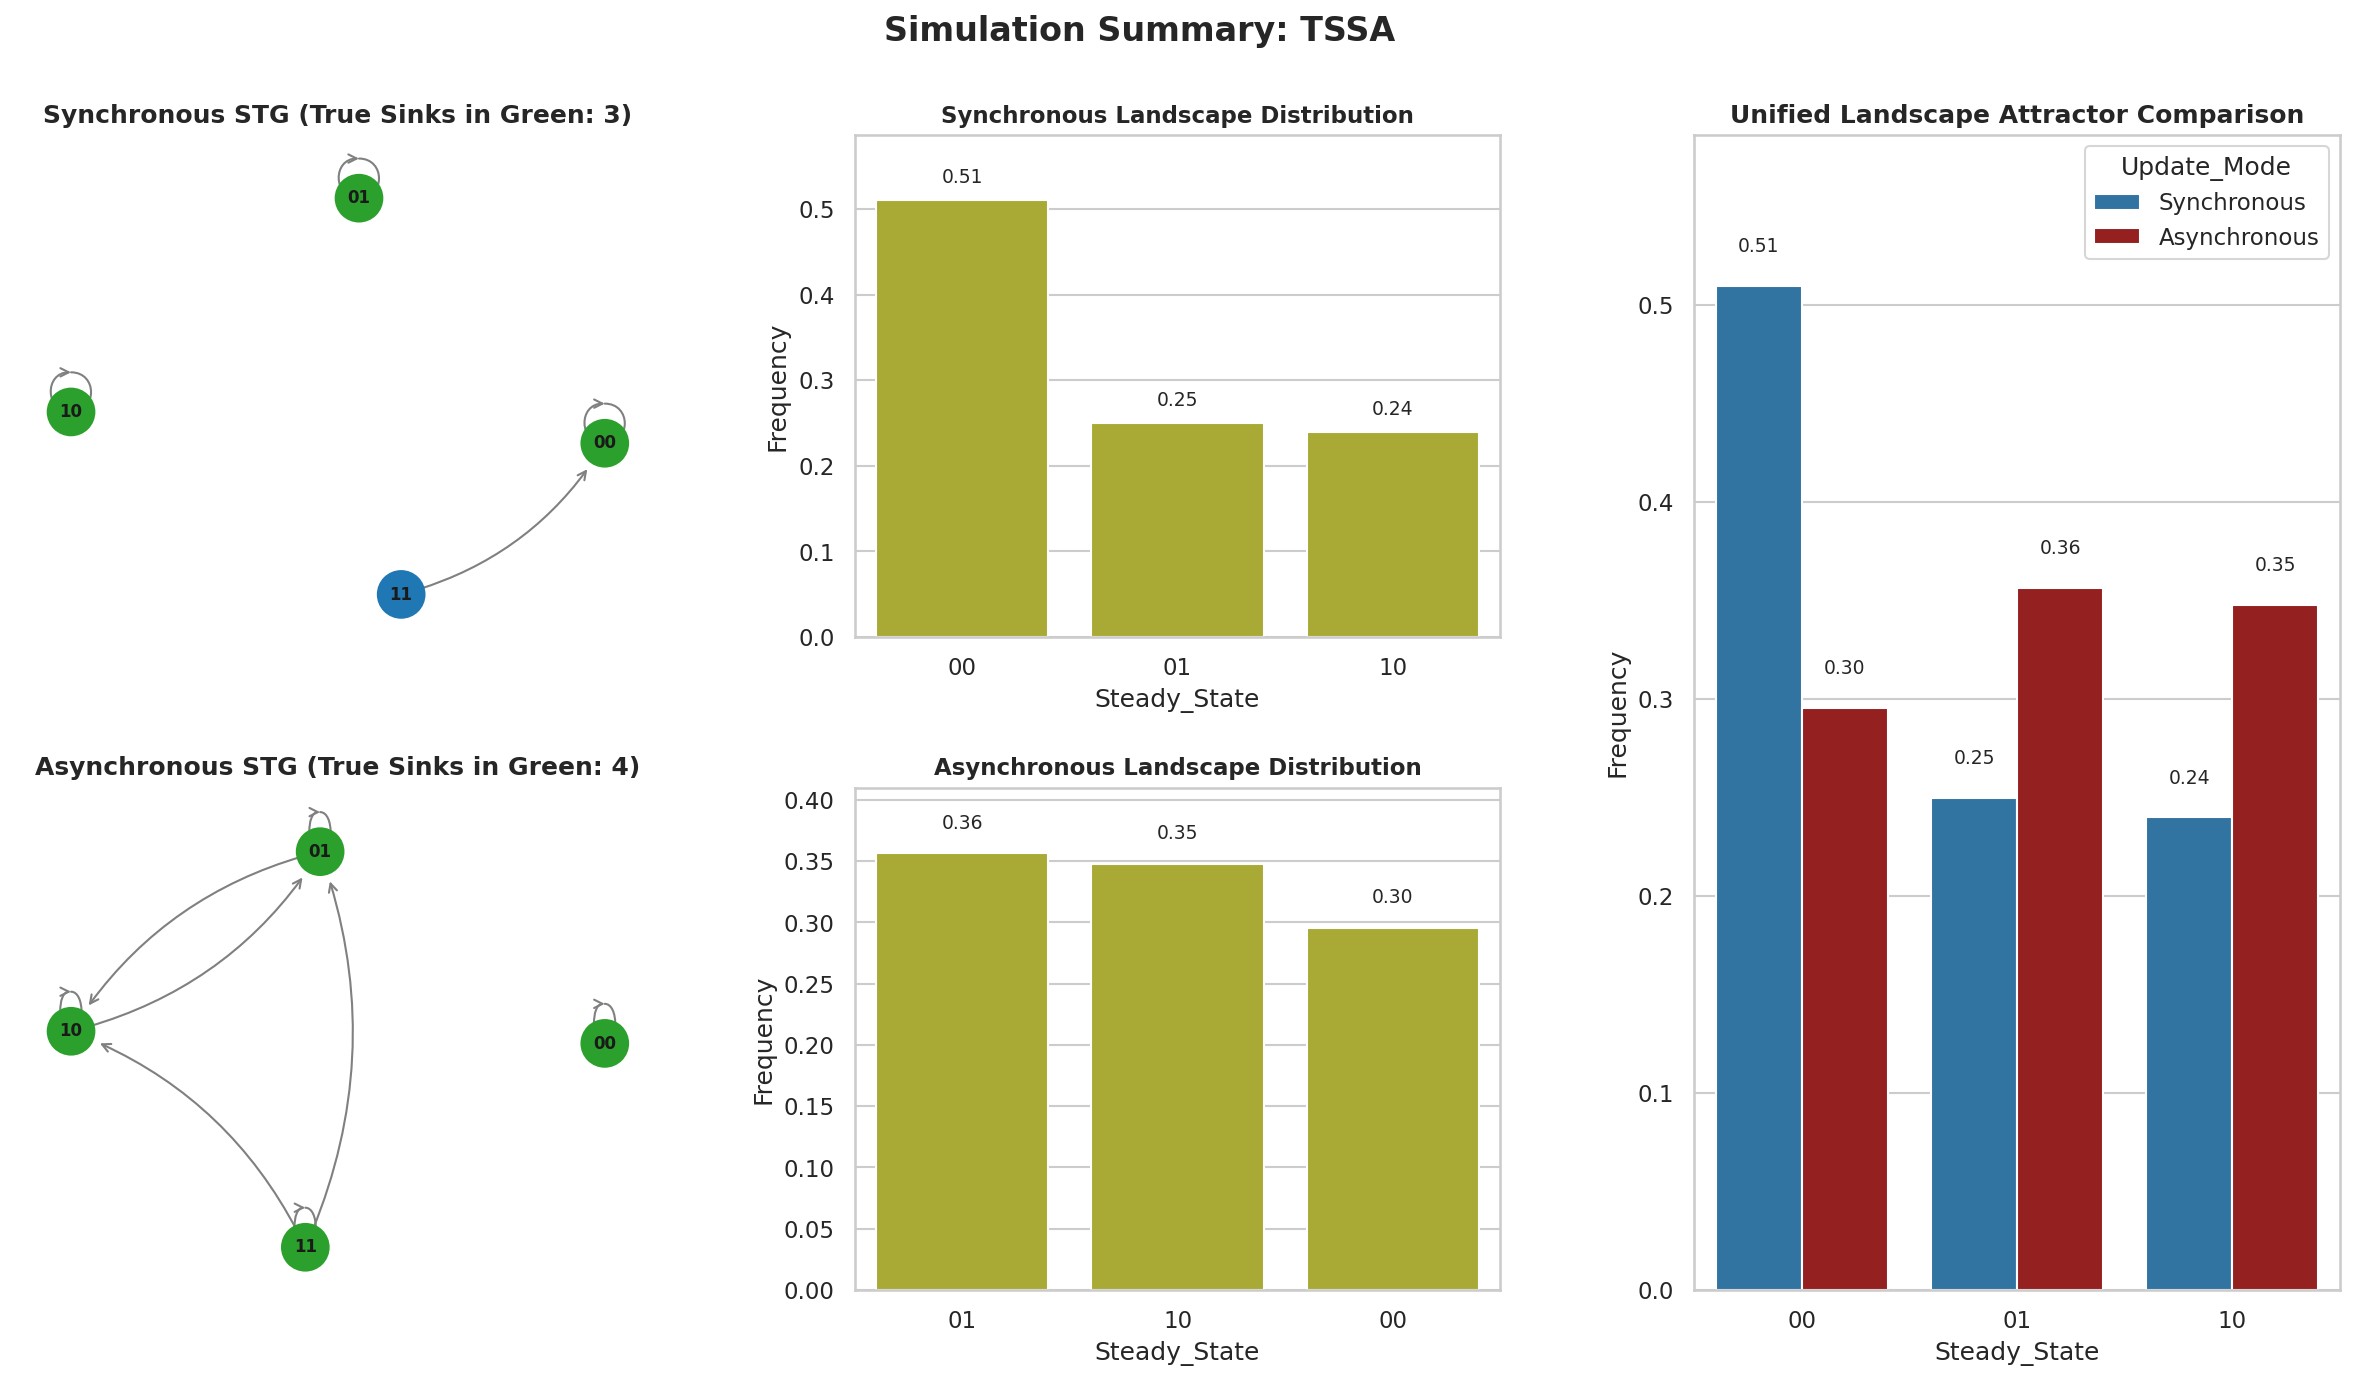


Processing Topology: TSSI
Running sync simulation pipeline...
--- SYNC Metrics ---
  Total unique states transitions: 4
  Stable steady-state points:  0 (None)
Running async simulation pipeline...
--- ASYNC Metrics ---
  Total unique states transitions: 12
  Stable steady-state points:  4 (11, 10, 01, 00)
Compiling consolidated summary for TSSI...


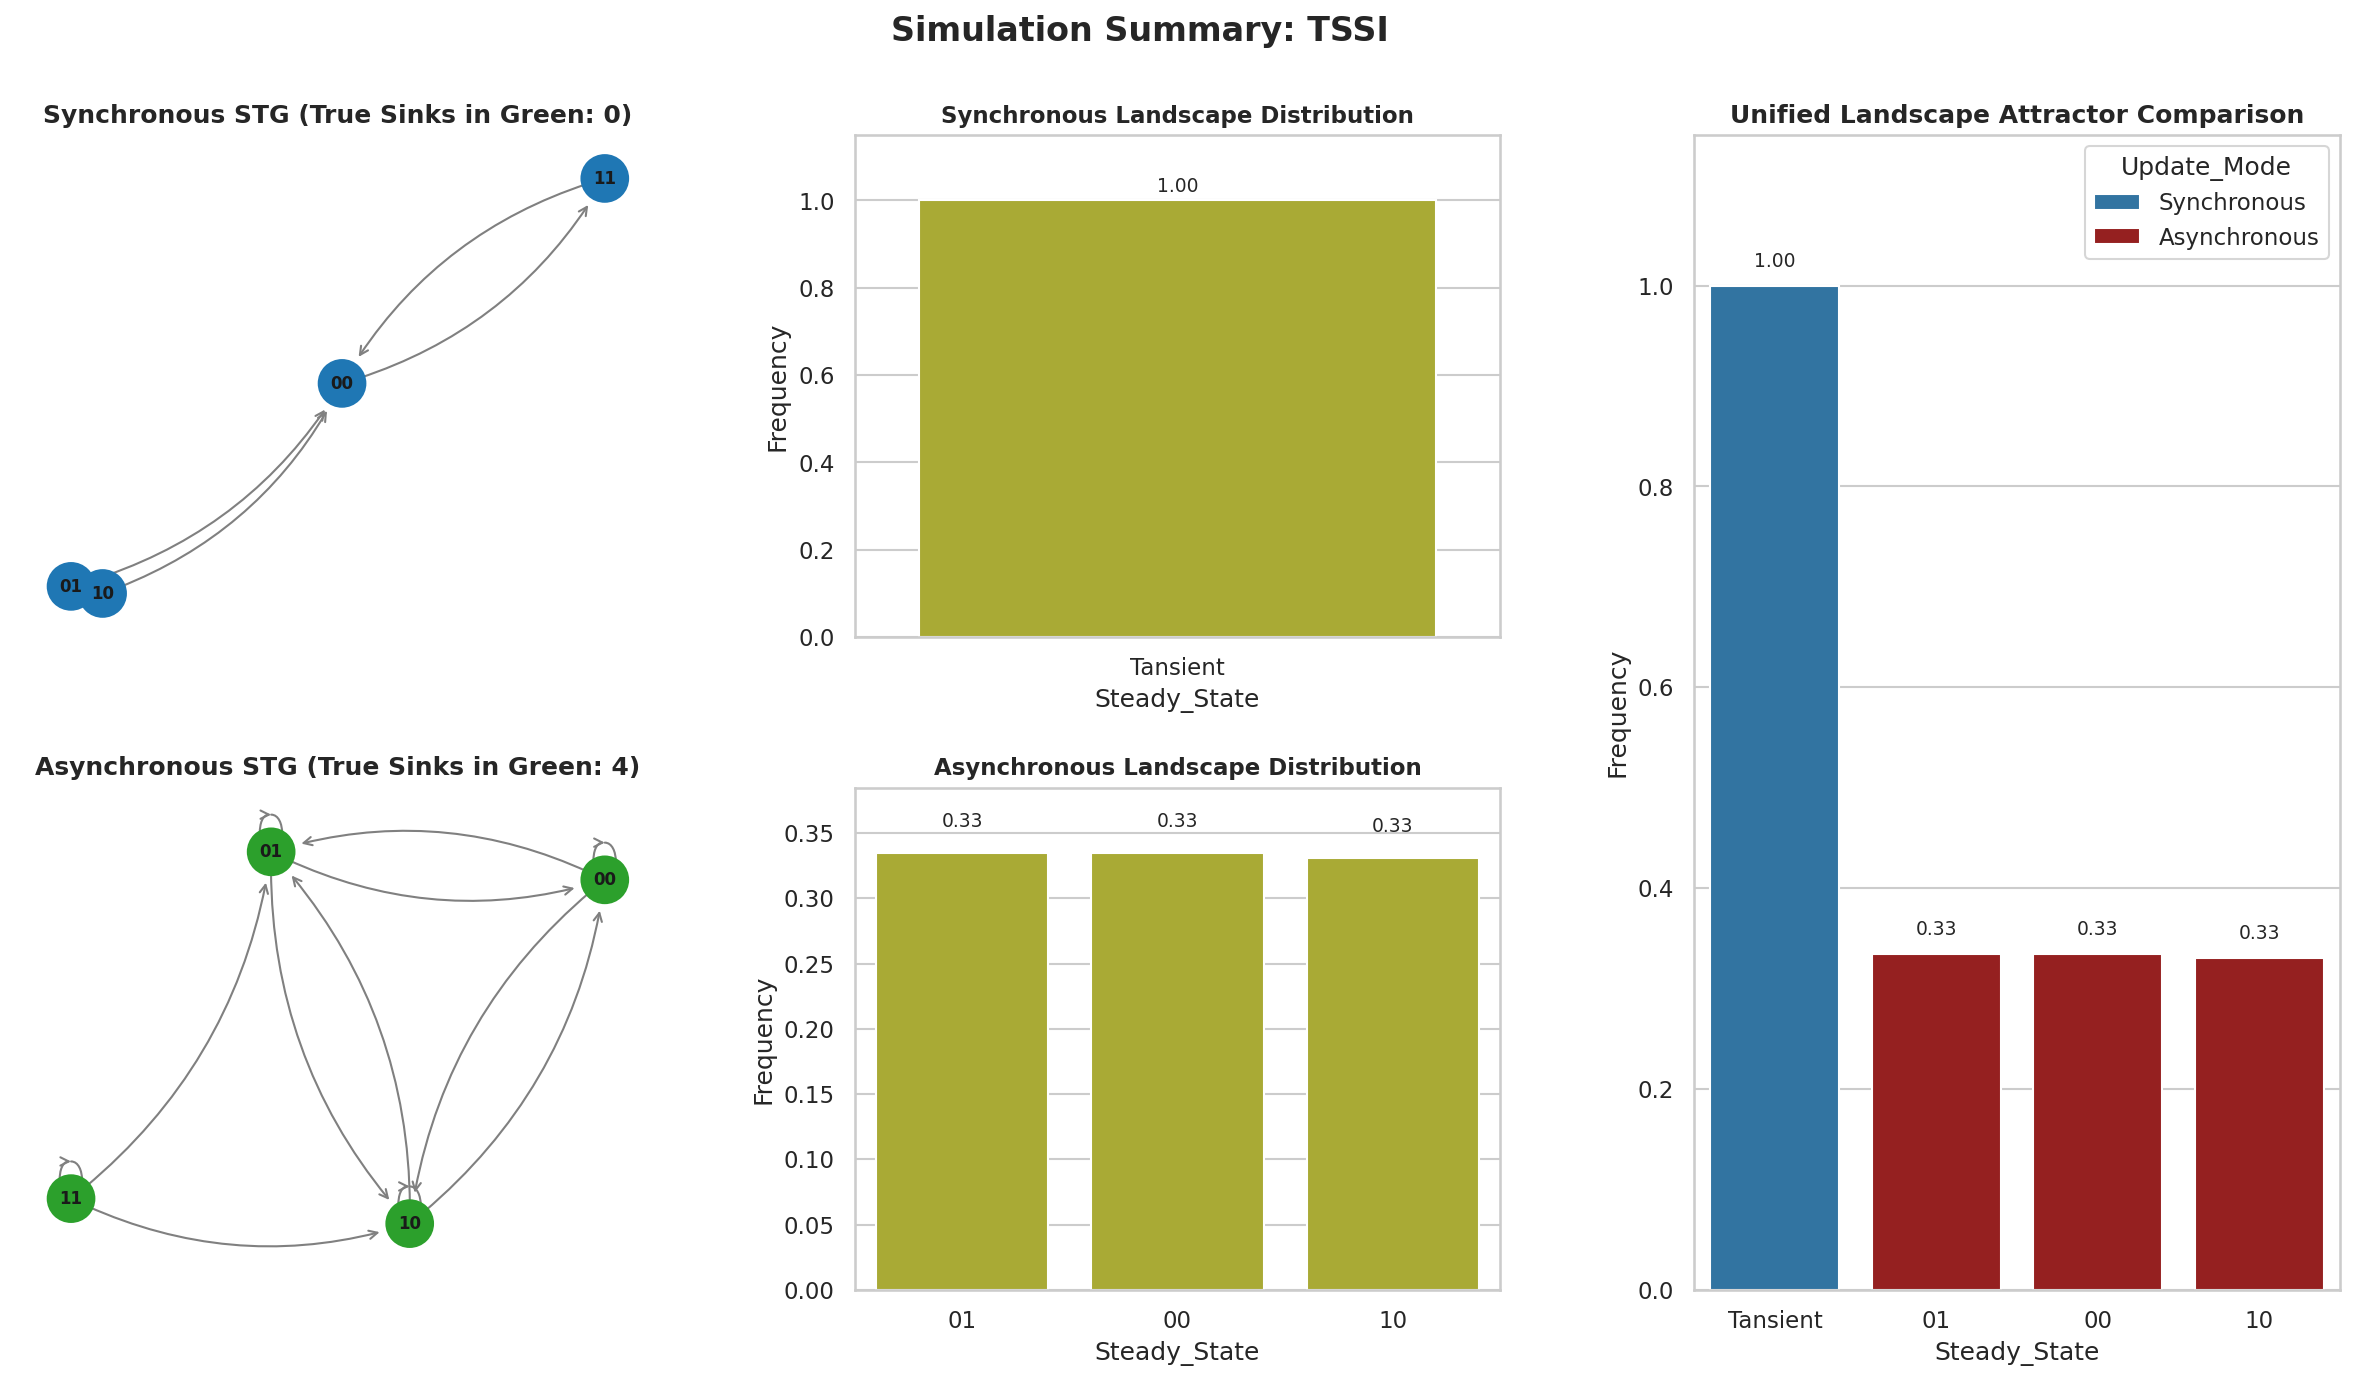


Processing Topology: TT
Running sync simulation pipeline...
--- SYNC Metrics ---
  Total unique states transitions: 8
  Stable steady-state points:  3 (100, 001, 010)
Running async simulation pipeline...
--- ASYNC Metrics ---
  Total unique states transitions: 44
  Stable steady-state points:  8 (000, 110, 011, 111, 010, 100, 101, 001)
Compiling consolidated summary for TT...


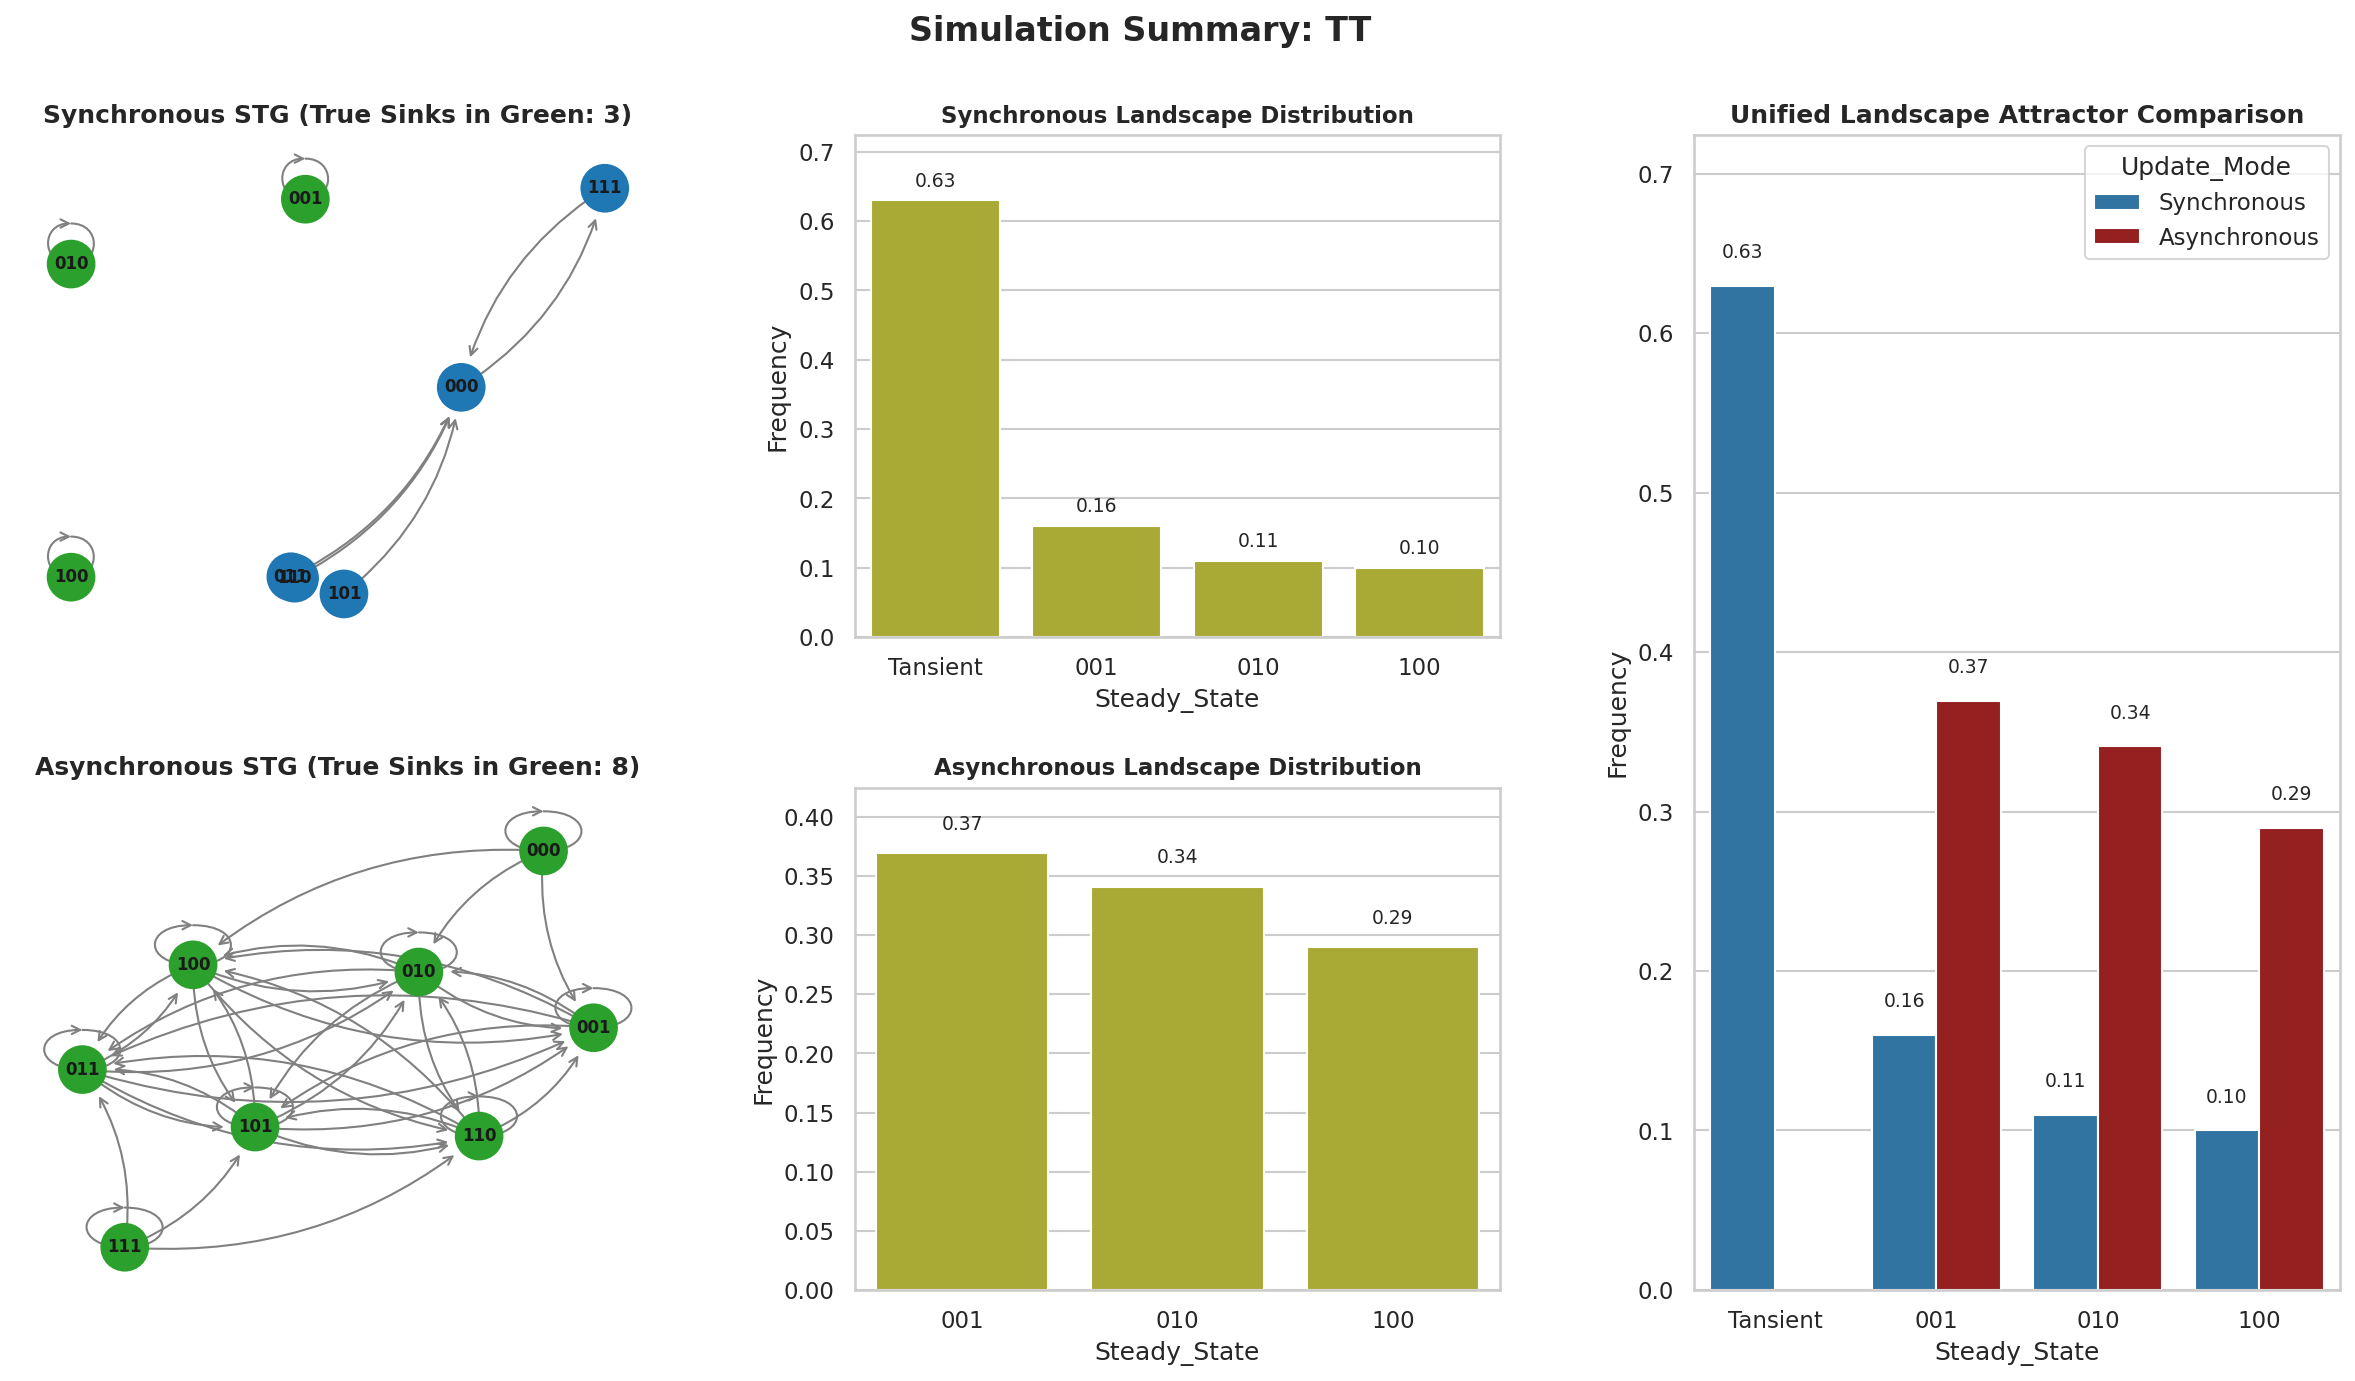


Processing Topology: TTSA
Running sync simulation pipeline...
--- SYNC Metrics ---
  Total unique states transitions: 8
  Stable steady-state points:  6 (110, 011, 010, 100, 101, 001)
Running async simulation pipeline...
--- ASYNC Metrics ---
  Total unique states transitions: 26
  Stable steady-state points:  8 (000, 110, 011, 111, 010, 100, 101, 001)
Compiling consolidated summary for TTSA...


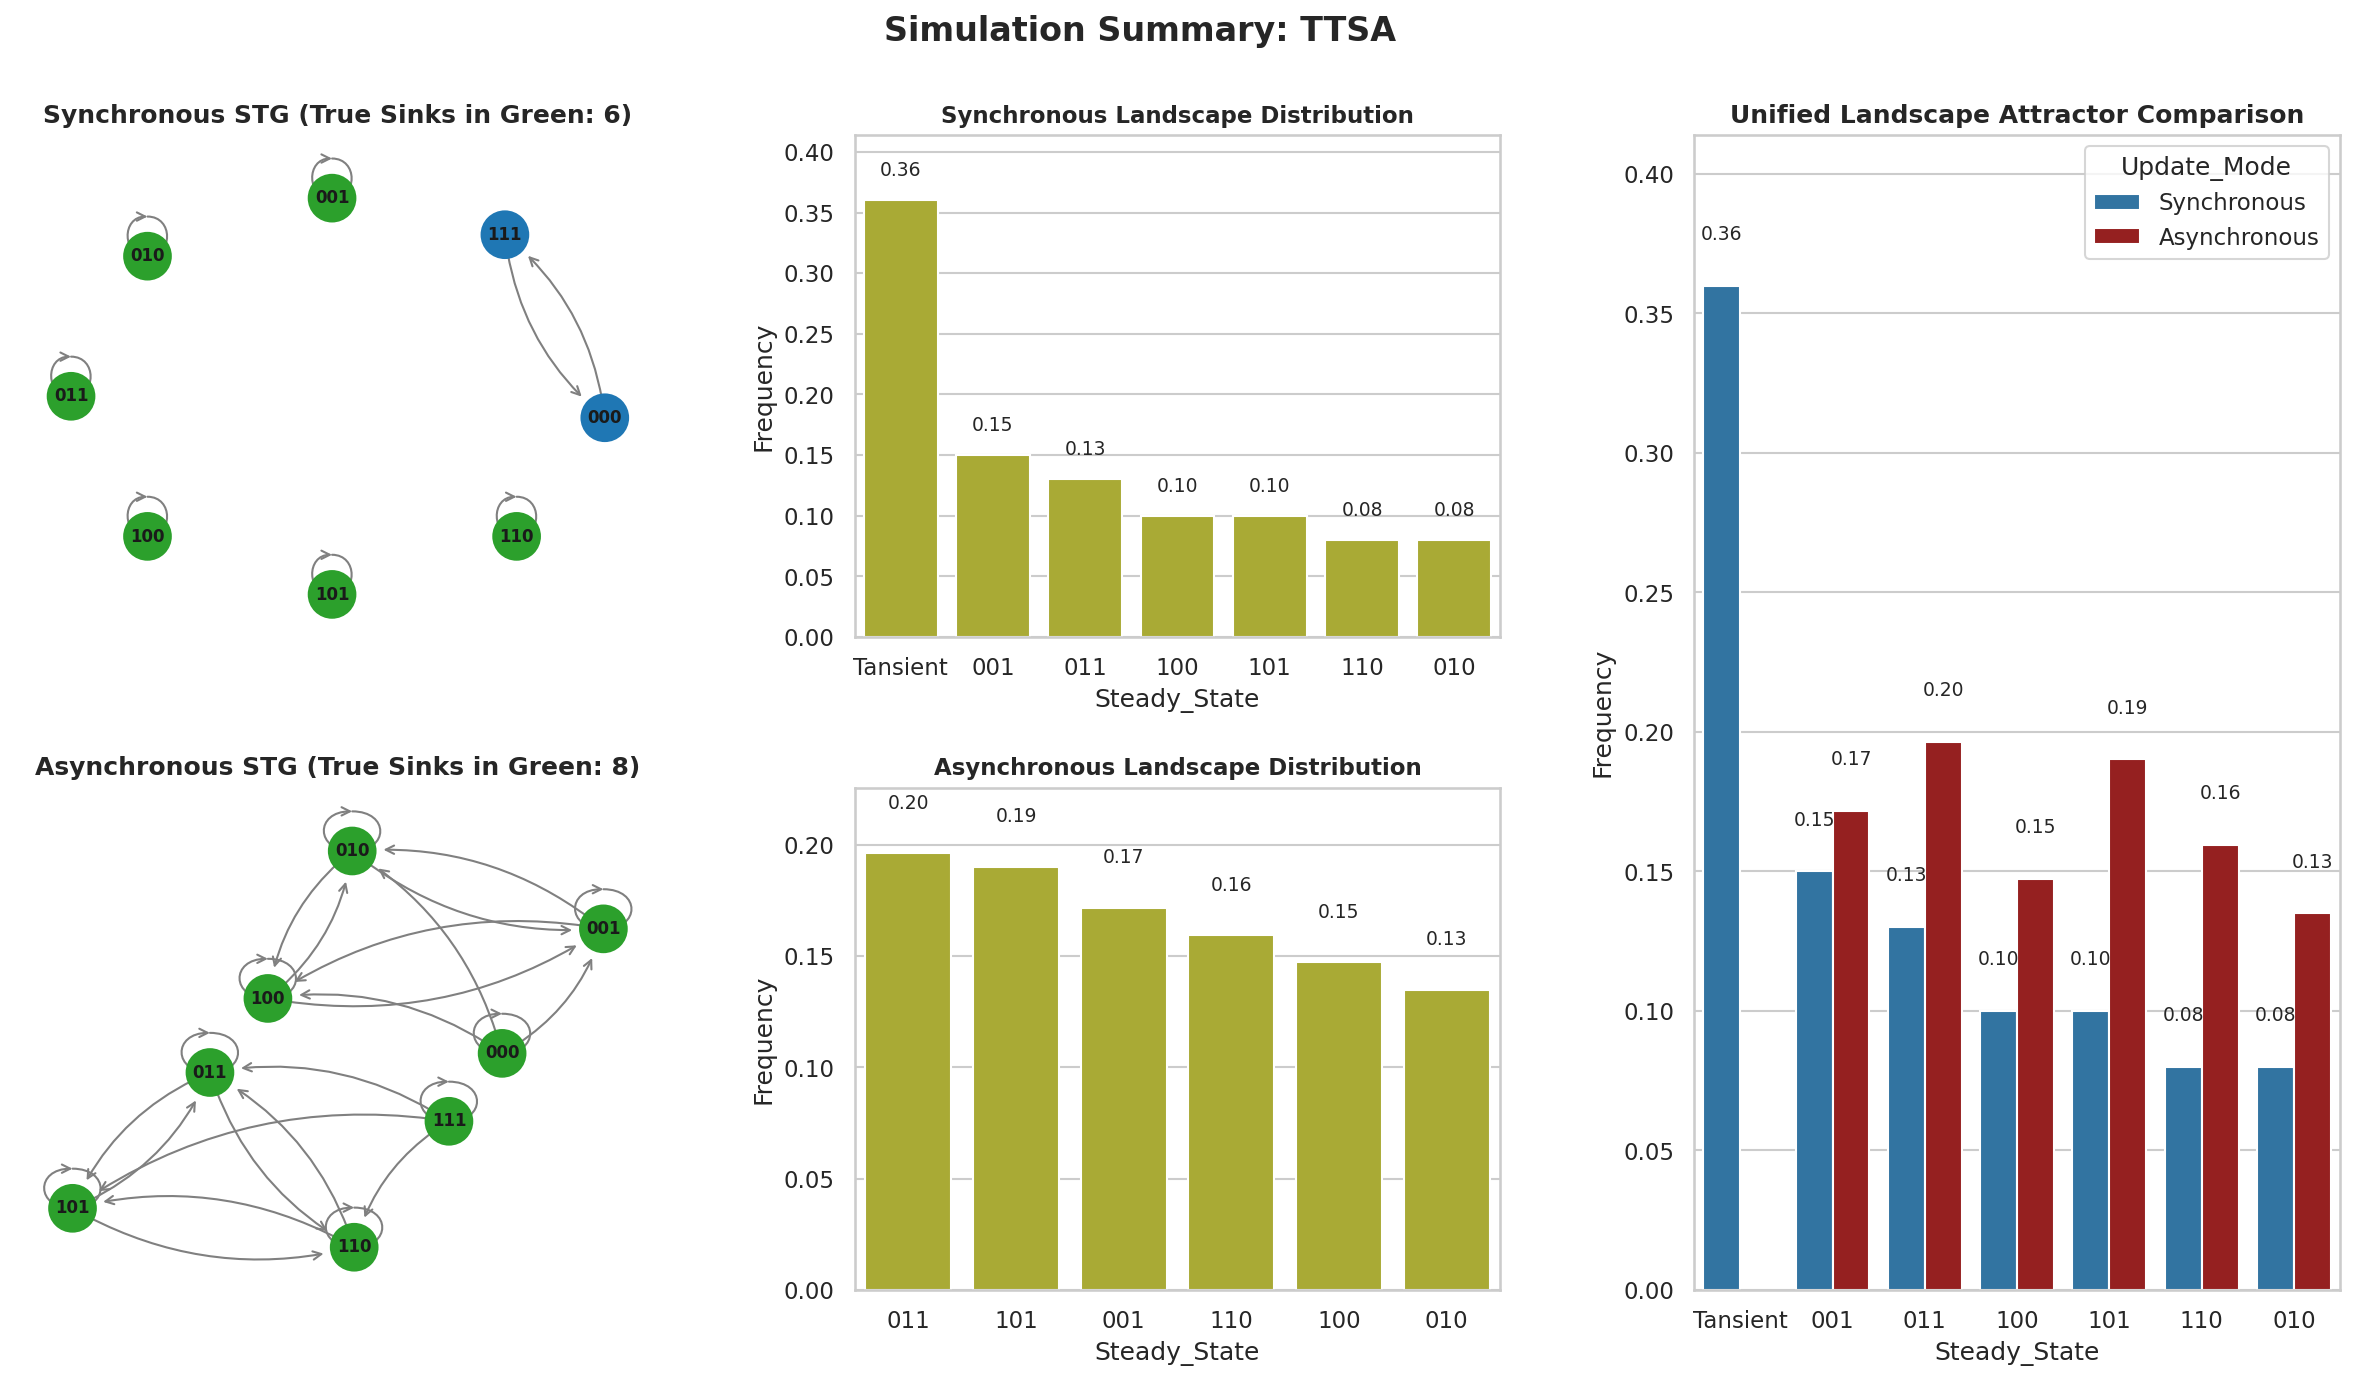

In [16]:
for topo_path in topo_list:
        topo_name = os.path.basename(topo_path).replace(".topo", "")
        print(f"\n{'='*50}\nProcessing Topology: {topo_name}\n{'='*50}")

        topo_adj, node_list = parse_topo(topo_path)
        os.makedirs(os.path.join(result_dir, topo_name), exist_ok=True)

        # Generate the shared initial conditions baseline
        init_conds = gen_initialconds(len(node_list), num_initconds=GLOBAL_NUM_ICS)

        # 1. Standard Execution Loop with Multi-Replicate Asynchronous Support
        for update_mode in ["sync", "async"]:
            print(f"Running {update_mode} simulation pipeline...")

            if update_mode == "sync":
                # Synchronous updates are perfectly deterministic; 1 replicate per IC is exhaustive
                simul_result = ising_simulate(topo_adj, init_conds, node_list, num_steps=STEPS_PER_RUN, update_mode="sync")
            else:
                # Asynchronous updates are stochastic; tile the initial condition matrix to execute repeated replicates
                replicated_ics = np.repeat(init_conds, ASYNC_REPLICATES, axis=0)
                simul_result = ising_simulate(topo_adj, replicated_ics, node_list, num_steps=STEPS_PER_RUN, update_mode="async")

                # Re-index InitCondNum to keep tracking grouped by original state configuration space
                # Instead of 1..500 unique IDs, it groups back into 1..100 distinct starting coordinate traces
                simul_result["InitCondNum"] = np.repeat(np.arange(1, GLOBAL_NUM_ICS + 1), ASYNC_REPLICATES * (STEPS_PER_RUN + 1))

            # Getting the STGs and frequency distributions
            edges, stable_states, freq_dist = get_stg_and_landscapes2(simul_result, node_list, GLOBAL_NUM_ICS)

            # Print diagnostic metrics (keeping your required format and terminal outputs)
            print(f"--- {update_mode.upper()} Metrics ---")
            print(f"  Total unique states transitions: {len(edges)}")
            print(f"  Stable steady-state points:  {len(stable_states)} ({', '.join(stable_states) if len(stable_states) > 0 else 'None'})")
            # print(f"  Transient states identified: {len(edges) - len(stable_states)}")

            # Persist data tables safely to disk
            simul_result.to_csv(os.path.join(result_dir, topo_name, f"{topo_name}_{update_mode}.csv"), index=False)
            edges.to_csv(os.path.join(result_dir, topo_name, f"{topo_name}_STG_{update_mode}.csv"), index=False)

            # Generate individual standalone plots
            # plot_stg_annotated(edges, stable_states, update_mode, topo_name, result_dir)
            # plot_steady_state_distribution(freq_dist, update_mode, topo_name, result_dir)

        # 2. Compile everything seamlessly into the unified subplotted layout master report
        print(f"Compiling consolidated summary for {topo_name}...")
        generate_consolidated_topology_report(topo_adj, node_list, topo_name, result_dir, init_conds, num_steps=STEPS_PER_RUN)